# Hate Speech Detection using NLP & Deep Learning

##  Project Overview
This project investigates hate speech detection using three different approaches:

1. **Traditional Machine Learning**
   - TF-IDF + Logistic Regression

2. **Deep Learning**
   - Bidirectional LSTM (BiLSTM)

3. **Transformer-Based Model**
   - DistilBERT (pretrained)


##  Objectives
- Compare traditional, sequential, and transformer-based models
- Evaluate performance using precision, recall, F1-score, and confusion matrix
- Analyse class imbalance and model behaviour
- Identify strengths and weaknesses of each model


##  Dataset Description
The dataset contains social media text classified into categories such as:
- Hate Speech
- Offensive Language
- Neutral Content

Import Libraries

In [5]:
#  Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Text Processing
import re
import string

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [6]:
# Load Dataset
df = pd.read_csv('/content/Dataset---Hate-Speech-Detection-using-Deep-Learning.csv')

# Display first few rows
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


Dataset Overview

In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns)

# Info
df.info()

Dataset Shape: (24783, 2)

Column Names: Index(['class', 'tweet'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   24783 non-null  int64 
 1   tweet   24783 non-null  object
dtypes: int64(1), object(1)
memory usage: 387.4+ KB


Check Missing Values

In [8]:
# Missing Values Check
df.isnull().sum()

,0
class,0
tweet,0


Class Distribution

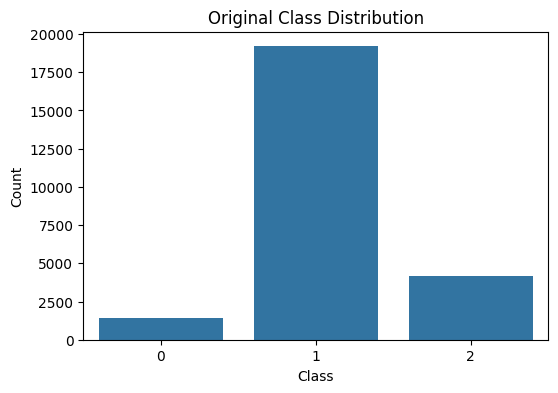

class
1    19190
2     4163
0     1430
Name: count, dtype: int64


In [9]:
#  Original Class Distribution

plt.figure(figsize=(6,4))
sns.countplot(x=df['class'])
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df['class'].value_counts())

Convert to Binary Classification

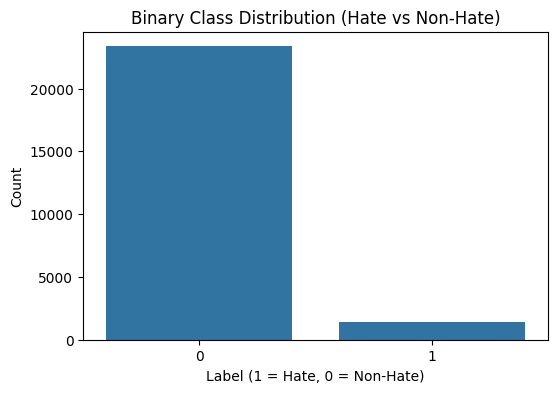

label
0    23353
1     1430
Name: count, dtype: int64


In [10]:
#  Convert to Binary Labels


# 0 = Hate → 1
# 1,2 = Non-hate → 0

df['label'] = df['class'].apply(lambda x: 1 if x == 0 else 0)

# Check new distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title("Binary Class Distribution (Hate vs Non-Hate)")
plt.xlabel("Label (1 = Hate, 0 = Non-Hate)")
plt.ylabel("Count")
plt.show()

print(df['label'].value_counts())

Text Length Analysis

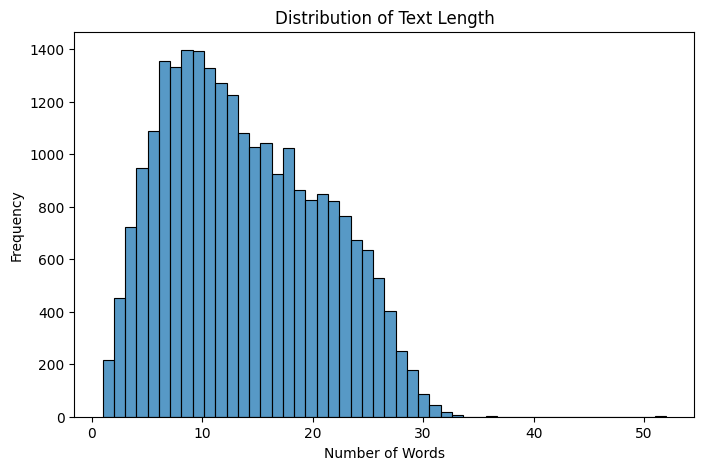

,text_length
count,24783.000000
mean,14.117016
std,6.825525
min,1.000000
25%,9.000000
50%,13.000000
75%,19.000000
max,52.000000


In [11]:
# Text Length Analysis

# Create text length column
df['text_length'] = df['tweet'].apply(lambda x: len(str(x).split()))

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Summary stats
df['text_length'].describe()

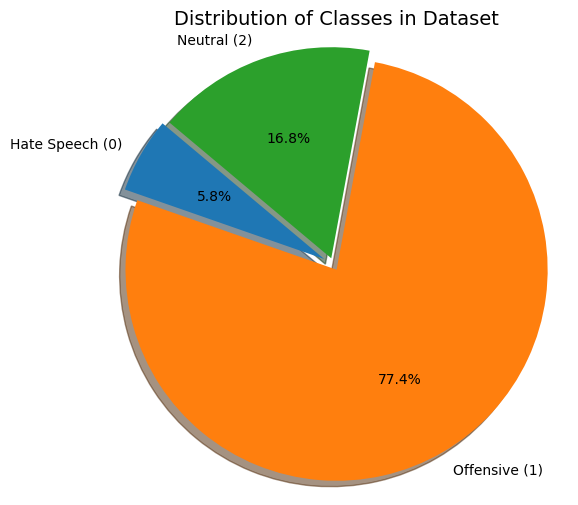

In [12]:
#  Class Distribution (Pie Chart)

# Get class distribution
class_counts = df['class'].value_counts().sort_index()

# Labels (custom for clarity)
labels = ['Hate Speech (0)', 'Offensive (1)', 'Neutral (2)']

# Plot
plt.figure(figsize=(6,6))

plt.pie(
    class_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05, 0.03, 0.03],  # slight highlight
    shadow=True
)

plt.title("Distribution of Classes in Dataset", fontsize=14)
plt.axis('equal')  # keeps circle shape
plt.show()

## Handling Class Imbalance

The dataset is imbalanced, with significantly fewer hate speech samples compared to other classes.

To address this, we apply a combination of:
- **Oversampling** (duplicate minority class)
- **Undersampling** (reduce majority class)

This helps improve model performance, especially recall for the minority (hate speech) class.

## Dataset Balancing

In [13]:
# Dataset Balancing

# Separate each class
class_0 = df[df['class'] == 0]  # Hate Speech (minority)
class_1 = df[df['class'] == 1]  # Offensive
class_2 = df[df['class'] == 2]  # Neutral


#  Apply Resampling Strategy
# Oversample minority class (Hate Speech)
class_0_oversampled = pd.concat([class_0, class_0, class_0], axis=0)

# Undersample majority class (Offensive)
class_1_undersampled = class_1.sample(n=3500, random_state=42)

# Keep neutral as it is
class_2_balanced = class_2

# Combine all classes
balanced_df = pd.concat([
    class_0_oversampled,
    class_1_undersampled,
    class_2_balanced
], axis=0)

# Shuffle dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced Dataset Shape:", balanced_df.shape)

Balanced Dataset Shape: (11953, 4)


Balanced Pie Chart

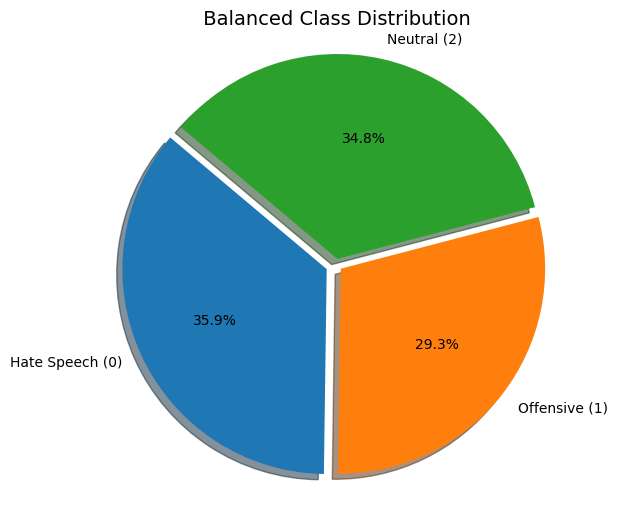

In [14]:
#  Balanced Class Distribution


balanced_counts = balanced_df['class'].value_counts().sort_index()

labels = ['Hate Speech (0)', 'Offensive (1)', 'Neutral (2)']

plt.figure(figsize=(6,6))

plt.pie(
    balanced_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05, 0.03, 0.03],
    shadow=True
)

plt.title(" Balanced Class Distribution", fontsize=14)
plt.axis('equal')
plt.show()

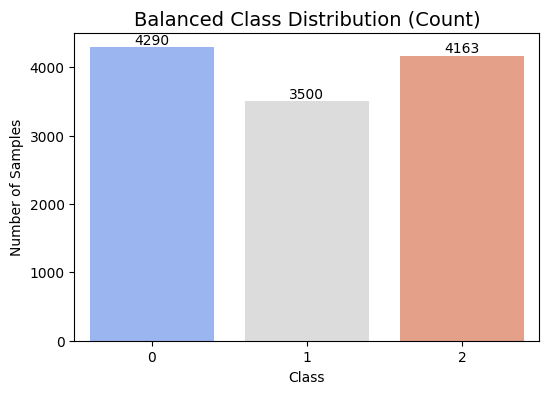

In [15]:
# Balanced Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=balanced_df, palette='coolwarm')

plt.title("Balanced Class Distribution (Count)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Samples")

# Add values on top
counts = balanced_df['class'].value_counts().sort_index().values
for i, v in enumerate(counts):
    plt.text(i, v + 50, str(v), ha='center')

plt.show()

## Text Preprocessing

Text data is inherently unstructured and noisy, especially in social media contexts.  
To improve model performance, preprocessing is applied to normalize and clean the text.

### Steps Applied:
- Lowercasing text
- Removing punctuation and special characters
- Removing stopwords (common non-informative words)
- Lemmatization (reducing words to base form)

 Note:
Different models require different preprocessing levels:
- **TF-IDF** → Heavy preprocessing
- **BiLSTM** → Moderate preprocessing
- **BERT** → Minimal preprocessing (preserves context)

This section focuses on preprocessing for traditional and deep learning models.

Import NLP Tools

In [16]:
#  NLP Preprocessing Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Cleaning Functions

In [17]:
#  Text Cleaning Functions
# Define stopwords and lemmatizer globally (efficient)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function: Remove punctuation
def remove_punctuation(text):
    return re.sub(f"[{re.escape(string.punctuation)}]", "", str(text))

# Function: Full preprocessing pipeline
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = remove_punctuation(text)

    # Tokenize and clean
    words = text.split()

    # Remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

Apply Preprocessing

In [18]:
# Apply to balanced dataset
balanced_df['clean_text'] = balanced_df['tweet'].apply(preprocess_text)

# Preview results
balanced_df[['tweet', 'clean_text']].head()

,tweet,clean_text
0,"@nytimes seems if they dont come up with it, i...",nytimes seems dont come trash nobody outside h...
1,"@karmendanielle_ aka he wanna keep you warm, s...",karmendanielle aka wanna keep warm shoulda int...
2,"RT @RollingWithTrin: ""1, 2, 3, 4, how many nig...",rt rollingwithtrin 1 2 3 4 many nigger store k...
3,@Shvkxir @RickiRoma @BaeSongz @JayZOverrated A...,shvkxir rickiroma baesongz jayzoverrated ahmed...
4,No these are only whites pies.\nWell do you ha...,white pie well negro pie


Word Cloud Visualization

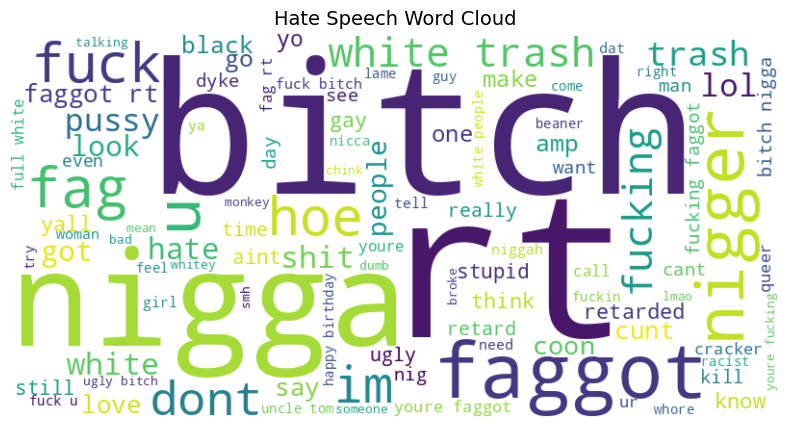

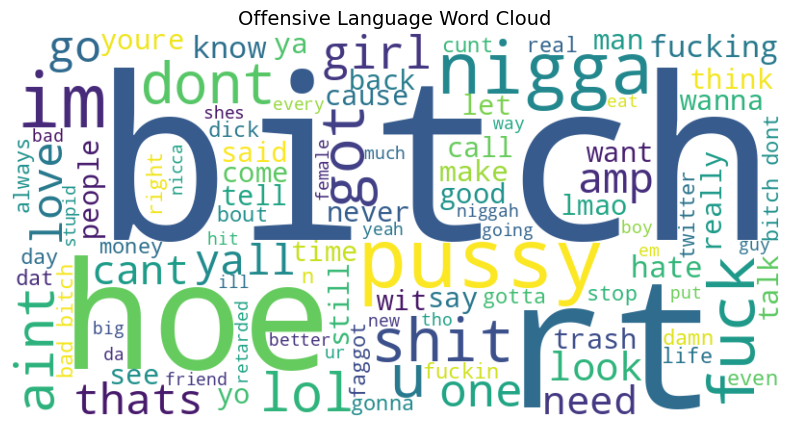

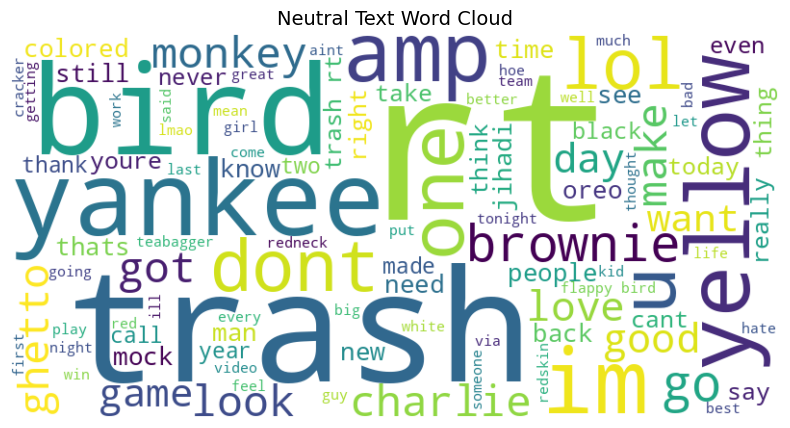

In [19]:
#  Word Cloud Visualization


from wordcloud import WordCloud

def plot_wordcloud(data, title):
    # Combine all text
    corpus = " ".join(data)

    # Generate word cloud
    wc = WordCloud(
        width=800,
        height=400,
        max_words=100,
        background_color='white',
        colormap='viridis'
    ).generate(corpus)

    # Plot
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.show()

#  Word Clouds per Class


plot_wordcloud(
    balanced_df[balanced_df['class'] == 0]['clean_text'],
    "Hate Speech Word Cloud"
)

plot_wordcloud(
    balanced_df[balanced_df['class'] == 1]['clean_text'],
    "Offensive Language Word Cloud"
)

plot_wordcloud(
    balanced_df[balanced_df['class'] == 2]['clean_text'],
    "Neutral Text Word Cloud"
)

# TF-IDF and  Logistic Regression Model

This model serves as a **baseline** for comparison with deep learning and transformer models.

Approach:
- Convert text into numerical features using **TF-IDF**
- Train a **Logistic Regression classifier**


Prepare Data (Use Clean Text)

In [20]:
#  Prepare Data for TF-IDF
# Use cleaned text
X = balanced_df['clean_text']

# Use binary label
y = balanced_df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (9562,)
Test Size: (2391,)


TF-IDF Vectorization

In [21]:
#  TF-IDF Vectorization


from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,     # limit vocabulary
    ngram_range=(1,2),     # unigrams + bigrams (IMPORTANT upgrade)
    min_df=2               # ignore rare words
)

# Fit on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

TF-IDF Train Shape: (9562, 5000)
TF-IDF Test Shape: (2391, 5000)


Train Logistic Regression

In [22]:
#  Logistic Regression Model

from sklearn.linear_model import LogisticRegression

# Initialize model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  # for imbalance
)

# Train model
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Predictions

In [23]:
#  Make Predictions

y_pred = lr_model.predict(X_test_tfidf)

Evaluation

In [24]:
#  Model Evaluation


print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1533
           1       0.83      0.87      0.85       858

    accuracy                           0.89      2391
   macro avg       0.88      0.88      0.88      2391
weighted avg       0.89      0.89      0.89      2391



Confusion Matrix

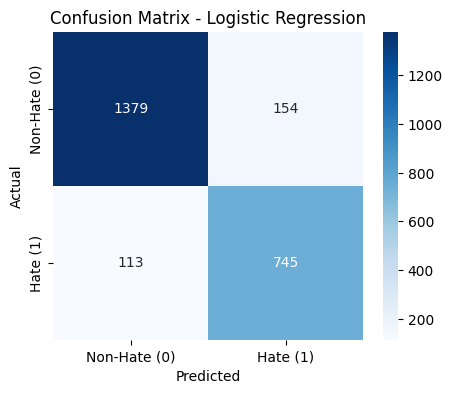

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

labels = ['Non-Hate (0)', 'Hate (1)']

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)


plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

In [26]:
#  Top Important Features

feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Top positive words (Hate)
top_hate = np.argsort(coefficients)[-10:]

# Top negative words (Non-hate)
top_non_hate = np.argsort(coefficients)[:10]

print("Top Hate Indicators:")
for i in top_hate:
    print(feature_names[i])

print("\nTop Non-Hate Indicators:")
for i in top_non_hate:
    print(feature_names[i])

Top Hate Indicators:
retard
kill
dyke
white trash
queer
white
nigga
fag
nigger
faggot

Top Non-Hate Indicators:
bird
yankee
charlie
bitch
yellow
brownie
mock
pussy
oreo
hoe


# Critical Analysis

The TF-IDF + Logistic Regression model provides a strong baseline due to its interpretability and efficiency. However, it treats text as independent tokens and fails to capture sequential dependencies and contextual meaning. As a result, it may misclassify sentences containing sarcasm or implicit hate speech, motivating the use of deep learning and transformer-based models.

BiLSTM Data Preparation

# BiLSTM Data Preparation

For deep learning models, text must be converted into numerical sequences.

This section prepares:
- Tokenized sequences
- Padded inputs
- Encoded labels

Note:
Separate variables are used to maintain clarity and avoid conflicts with other models.

In [27]:
# BiLSTM Dataset Variables

X_bilstm = balanced_df['clean_text']
y_bilstm = balanced_df['label']   # Use binary label (recommended)

# Train-validation split
X_train_bi, X_val_bi, y_train_bi, y_val_bi = train_test_split(
    X_bilstm,
    y_bilstm,
    test_size=0.2,
    stratify=y_bilstm,
    random_state=42
)

print("Train Size:", X_train_bi.shape)
print("Validation Size:", X_val_bi.shape)

Train Size: (9562,)
Validation Size: (2391,)


Tokenization (BiLSTM)

In [28]:
#  Tokenization (BiLSTM)


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
MAX_WORDS_BI = 10000
MAX_LEN_BI = 100

# Initialize tokenizer
tokenizer_bi = Tokenizer(num_words=MAX_WORDS_BI, oov_token="<OOV>")

# Fit only on training data
tokenizer_bi.fit_on_texts(X_train_bi)

# Convert text → sequences
X_train_seq_bi = tokenizer_bi.texts_to_sequences(X_train_bi)
X_val_seq_bi = tokenizer_bi.texts_to_sequences(X_val_bi)

Padding

In [29]:
#  Padding Sequences

X_train_pad_bi = pad_sequences(
    X_train_seq_bi,
    maxlen=MAX_LEN_BI,
    padding='post',
    truncating='post'
)

X_val_pad_bi = pad_sequences(
    X_val_seq_bi,
    maxlen=MAX_LEN_BI,
    padding='post',
    truncating='post'
)

print("Train Shape:", X_train_pad_bi.shape)
print("Validation Shape:", X_val_pad_bi.shape)

Train Shape: (9562, 100)
Validation Shape: (2391, 100)


## BiLSTM Model Architecture

The Bidirectional LSTM processes sequences in both forward and backward directions.

## Components:
- Embedding Layer → word representation
- Bidirectional LSTM → contextual learning
- Dense Layer → feature extraction
- Batch Normalization → stable training
- Dropout → prevent overfitting
- Output Layer → binary classification

This model captures sequential dependencies better than TF-IDF.

Build BiLSTM Model

In [30]:
#  Build BiLSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization

bilstm_model = Sequential([

    # Input Layer
    Input(shape=(MAX_LEN_BI,)),

    # Embedding Layer
    Embedding(input_dim=MAX_WORDS_BI, output_dim=64),

    # Bidirectional LSTM
    Bidirectional(LSTM(64)),

    # Dense Layer
    Dense(128, activation='relu'),

    # Batch Normalization
    BatchNormalization(),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Compile
bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 723,201 (2.76 MB)

 Trainable params: 722,945 (2.76 MB)

 Non-trainable params: 256 (1.00 KB)

Callbacks

In [31]:
#  Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop_bi = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr_bi = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

Train Model

In [ ]:
#  Train BiLSTM Model

history_bi = bilstm_model.fit(
    X_train_pad_bi, y_train_bi,
    validation_data=(X_val_pad_bi, y_val_bi),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop_bi, reduce_lr_bi]
)

Epoch 1/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8673 - loss: 0.3068 - val_accuracy: 0.8603 - val_loss: 0.3646 - learning_rate: 0.0010
Epoch 2/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9603 - loss: 0.1218 - val_accuracy: 0.8967 - val_loss: 0.3586 - learning_rate: 0.0010
Epoch 3/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9787 - loss: 0.0708 - val_accuracy: 0.9423 - val_loss: 0.1916 - learning_rate: 0.0010
Epoch 4/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9871 - loss: 0.0429 - val_accuracy: 0.9540 - val_loss: 0.1871 - learning_rate: 0.0010
Epoch 5/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9882 - loss: 0.0390 - val_accuracy: 0.9414 - val_loss: 0.2228 - learning_rate: 0.0010
Epoch 6/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9921 - loss: 0.0306 - val_accuracy: 0.9594 - val_loss: 0.1673 - learning_rate: 0.0010
Epoch 7/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9933 - loss: 0

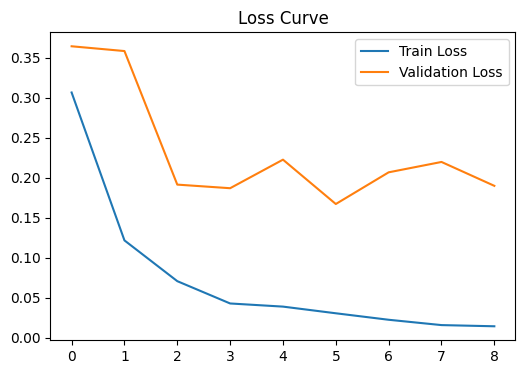

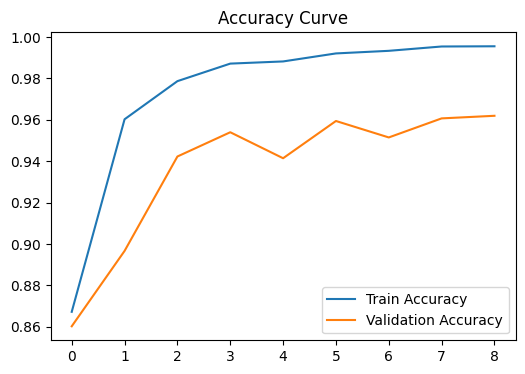

In [ ]:
#  Training Curves
history_df = pd.DataFrame(history_bi.history)

# Loss
plt.figure(figsize=(6,4))
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(6,4))
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

In [ ]:
#  Predictions & Evaluation

y_pred_bi = (bilstm_model.predict(X_val_pad_bi) > 0.5).astype("int32")

print("Classification Report:\n")
print(classification_report(y_val_bi, y_pred_bi))

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1533
           1       0.93      0.96      0.94       858

    accuracy                           0.96      2391
   macro avg       0.95      0.96      0.96      2391
weighted avg       0.96      0.96      0.96      2391



In [ ]:
#  Final Evaluation (Accuracy)
loss_bi, acc_bi = bilstm_model.evaluate(X_val_pad_bi, y_val_bi)

print(f"Validation Accuracy: {acc_bi:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9594 - loss: 0.1673
Validation Accuracy: 0.9594


Confusion Matrix

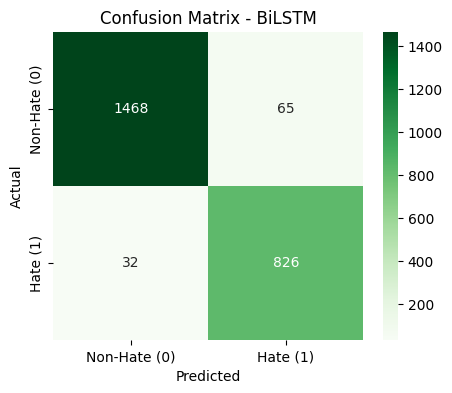

In [ ]:
#  Confusion Matrix

cm_bi = confusion_matrix(y_val_bi, y_pred_bi)

labels = ['Non-Hate (0)', 'Hate (1)']

plt.figure(figsize=(5,4))
sns.heatmap(cm_bi, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model 3: DistilBERT (Transformer-Based Model)

DistilBERT is a lightweight transformer model that uses attention mechanisms to capture contextual relationships in text. It leverages pretrained knowledge, allowing it to understand semantic meaning more effectively than traditional and sequential models.

## Key Advantages:
Captures contextual meaning of words
Handles long-range dependencies
Pretrained on large datasets → better generalization

DistilBERT (Transformer-Based Model)

In [37]:
!pip install transformers datasets

In [38]:
#  Import Libraries
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset



Prepare Data (cleaned text)

In [39]:
X_bert = balanced_df['clean_text']
y_bert = balanced_df['label']

# Train Test Split
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_bert,
    y_bert,
    test_size=0.2,
    stratify=y_bert,
    random_state=42
)

Convert to HuggingFace Dataset

In [40]:
#  Convert to HuggingFace Dataset
train_dataset = Dataset.from_dict({
    "text": list(X_train_bert),
    "label": list(y_train_bert)
})

val_dataset = Dataset.from_dict({
    "text": list(X_val_bert),
    "label": list(y_val_bert)
})


In [41]:
#  Tokenization
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(example):
    return tokenizer(
        example['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/9562 [00:00<?, ? examples/s]

Map:   0%|          | 0/2391 [00:00<?, ? examples/s]

Load Model

In [42]:
#  Load Model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [43]:
#  Training Setup

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=12,
    eval_strategy="epoch",
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Train Model

In [ ]:
#  Train Model

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.401519,0.274009
2,0.223546,0.209300
3,0.127592,0.219958
4,0.092021,0.247584
5,0.049001,0.269652
6,0.017001,0.387060
7,0.008563,0.425717
8,0.004185,0.328981
9,0.005703,0.373061
10,0.006678,0.399305


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7176, training_loss=0.06735625414506385, metrics={'train_runtime': 1843.3836, 'train_samples_per_second': 62.246, 'train_steps_per_second': 3.893, 'total_flos': 3799959797846016.0, 'train_loss': 0.06735625414506385, 'epoch': 12.0})

In [ ]:
#  Evaluation

predictions = trainer.predict(val_dataset)

y_pred_bert = np.argmax(predictions.predictions, axis=1)

print("Classification Report:\n")
print(classification_report(y_val_bert, y_pred_bert))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1533
           1       0.90      0.98      0.94       858

    accuracy                           0.96      2391
   macro avg       0.95      0.96      0.95      2391
weighted avg       0.96      0.96      0.96      2391



Confusion Matrix

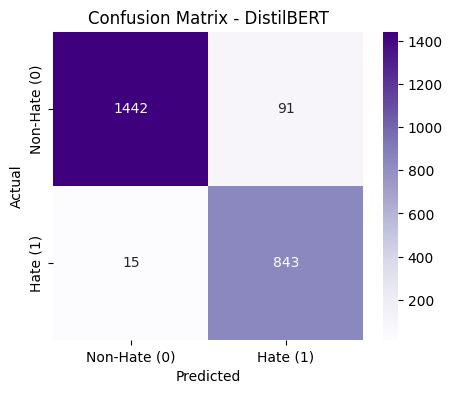

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_bert = confusion_matrix(y_val_bert, y_pred_bert)

labels = ['Non-Hate (0)', 'Hate (1)']

plt.figure(figsize=(5,4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model Comparison

In [ ]:
#  Model Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# TF-IDF
acc_lr = accuracy_score(y_test, y_pred)
prec_lr = precision_score(y_test, y_pred)
rec_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)

# BiLSTM
acc_bi = accuracy_score(y_val_bi, y_pred_bi)
prec_bi = precision_score(y_val_bi, y_pred_bi)
rec_bi = recall_score(y_val_bi, y_pred_bi)
f1_bi = f1_score(y_val_bi, y_pred_bi)

# DistilBERT
acc_bert = accuracy_score(y_val_bert, y_pred_bert)
prec_bert = precision_score(y_val_bert, y_pred_bert)
rec_bert = recall_score(y_val_bert, y_pred_bert)
f1_bert = f1_score(y_val_bert, y_pred_bert)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + LR", "BiLSTM", "DistilBERT"],
    "Accuracy": [acc_lr, acc_bi, acc_bert],
    "Precision": [prec_lr, prec_bi, prec_bert],
    "Recall": [rec_lr, rec_bi, rec_bert],
    "F1-score": [f1_lr, f1_bi, f1_bert]
})

# Display table
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + LR,0.888331,0.828699,0.868298,0.848036
1,BiLSTM,0.959431,0.927048,0.962704,0.944540
2,DistilBERT,0.955667,0.902570,0.982517,0.940848


# Model Comparison
A comparative analysis was conducted across three models: TF-IDF with Logistic Regression, BiLSTM, and DistilBERT.

The TF-IDF model achieved an accuracy of 0.89, serving as a strong baseline. However, its relatively lower precision (0.83) and F1-score (0.85) indicate that it produces more false positives and lacks the ability to capture contextual meaning, as it treats text as independent tokens.

The BiLSTM model achieved the best overall performance with an accuracy of 0.96 and the highest F1-score (0.94). This demonstrates its effectiveness in capturing sequential dependencies and contextual relationships within text, resulting in a well-balanced performance across precision (0.93) and recall (0.96).

DistilBERT achieved an accuracy of 0.96, closely matching BiLSTM, and the highest recall (0.98) for the hate speech class. This indicates that the model is highly effective at identifying harmful content. However, its slightly lower precision (0.90) suggests a tendency to produce more false positives compared to BiLSTM.

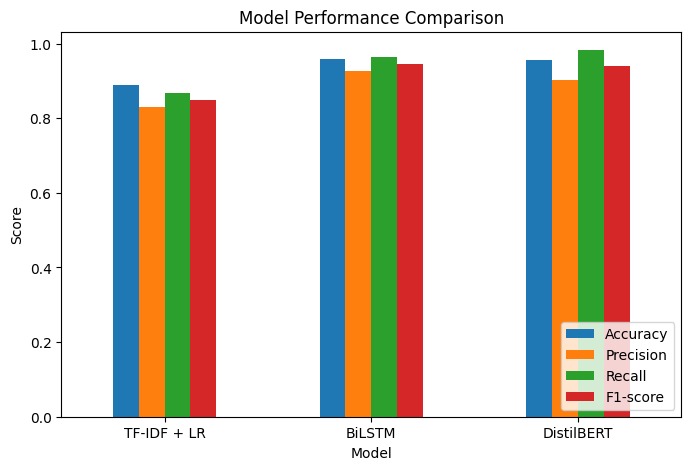

In [ ]:
#  Plot Model Comparison

comparison_df.set_index("Model").plot(kind='bar', figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# CRITICAL ANALYSIS

The results highlight a trade-off between precision and recall across models. DistilBERT prioritizes recall, making it highly effective at detecting hate speech, which is critical in safety-sensitive applications. However, this comes at the cost of slightly lower precision.

In contrast, BiLSTM provides a more balanced performance across all metrics, achieving the highest F1-score and overall accuracy, making it the most reliable model in this study.

The TF-IDF model, while efficient and interpretable, lacks the ability to capture semantic and contextual relationships, limiting its performance compared to deep learning and transformer-based approaches.

# FINAL CONCLUSION

Overall, BiLSTM emerged as the best-performing model in terms of balanced accuracy and F1-score, while DistilBERT demonstrated superior recall, making it particularly effective for identifying hate speech. The choice between these models depends on the application context, where recall may be prioritised over precision in sensitive domains.

# Real-Time Hate Speech Detector

In [ ]:
def preprocess_input(text):
    text = text.lower()
    text = remove_punctuation(text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

In [ ]:
def predict_text(text):

    #  Apply same preprocessing
    text = preprocess_input(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs).item()
    confidence = torch.max(probs).item()

    if pred == 1:
        return f" Hate Speech Detected (Confidence: {confidence:.2f})"
    else:
        return f" Non-Hate Speech (Confidence: {confidence:.2f})"

Test Examples

In [ ]:
print(predict_text("I hate you"))
print(predict_text("You are wonderful"))

 Hate Speech Detected (Confidence: 1.00)
 Non-Hate Speech (Confidence: 1.00)
